In [7]:
# Import necessary libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import roc_auc_score, classification_report

import pandas as pd
import autokeras as ak
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os

from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

print(tf.config.list_physical_devices('GPU'))

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Cell 2: Data Loading and Preprocessing
# Load the datasets
df_hemo = pd.read_csv(os.path.expanduser('~/merged_hemorrhage_embeddings.csv'))
df_control = pd.read_csv(os.path.expanduser('~/merged_control_embeddings.csv'))

# Combine the datasets
df = pd.concat([df_hemo, df_control], ignore_index=True)

# Convert the 'embedding' column from string to a list
df['embedding'] = df['embedding'].apply(eval)

# Define the target columns in the proper order
target_columns = ['any', 'epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']

# Extract features and labels
X = np.array(df['embedding'].tolist(), dtype=np.float32)
y = df[target_columns].values.astype(np.float32)

# Split the data (20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("y_train shape:", y_train.shape)


X_train_scaled shape: (12900, 1408)
y_train shape: (12900, 6)


In [3]:
# Extract only the 'any' column from the labels for binary classification
y_train_any = y_train[:, 0]  # 'any' column
y_test_any = y_test[:, 0]    # 'any' column

In [4]:
# Define a simple binary classification model
def create_simple_binary_model(input_dim, neurons=128, dropout_rate=0.3, learning_rate=1e-3):
    """
    Create a simple binary classification model for detecting any hemorrhage.
    
    Args:
        input_dim: Dimension of input features (embedding size)
        neurons: Number of neurons in the hidden layer
        dropout_rate: Dropout rate for regularization
        learning_rate: Learning rate for the optimizer
    
    Returns:
        Compiled Keras model
    """
    model = Sequential()
    
    # Input layer
    model.add(Dense(neurons, input_dim=input_dim, kernel_initializer='he_normal'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(dropout_rate))
    
    # Output layer with sigmoid activation for binary classification
    model.add(Dense(1, activation='sigmoid'))
    
    # Compile the model
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    
    return model

In [5]:
# Set hyperparameters for the simple binary model
input_dim = X_train_scaled.shape[1]
neurons = 128  # Number of neurons in the hidden layer
dropout_rate = 0.3  # Dropout rate for regularization
learning_rate = 1e-3  # Learning rate for the optimizer

# Create the simple binary classification model
binary_model = create_simple_binary_model(input_dim=input_dim, neurons=neurons, 
                                          dropout_rate=dropout_rate, learning_rate=learning_rate)

# Define callbacks for training
callbacks = [
    EarlyStopping(monitor='val_auc', patience=5, mode='max', restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=3, min_lr=1e-6, mode='max'),
    ModelCheckpoint('best_binary_model.h5', monitor='val_auc', mode='max', save_best_only=True)
]

# Train the binary classification model
history = binary_model.fit(
    X_train_scaled, y_train_any,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# Evaluate the binary classification model on test data
y_pred_any = binary_model.predict(X_test_scaled).flatten()
auc_score = roc_auc_score(y_test_any, y_pred_any)
print(f"Test AUC for 'any' hemorrhage detection: {auc_score:.4f}")

# Convert predictions to binary using a threshold of 0.5 and print classification report
y_pred_any_binary = (y_pred_any > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test_any, y_pred_any_binary))

/home/bahram/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1742947869.570649    3034 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1753 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/50


I0000 00:00:1742947873.259691    3134 service.cc:148] XLA service 0x7fc358016280 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1742947873.260258    3134 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Ti Laptop GPU, Compute Capability 8.6
2025-03-25 19:11:13.403677: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1742947873.719945    3134 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1742947874.633430    3134 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7944 - auc: 0.8574 - loss: 0.4747  

323/323 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7944 - auc: 0.8575 - loss: 0.4746 - val_accuracy: 0.8298 - val_auc: 0.8883 - val_loss: 0.4125 - learning_rate: 0.0010
Epoch 2/50
311/323 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8210 - auc: 0.8851 - loss: 0.4186

...

323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8562 - auc: 0.9245 - loss: 0.3391 - val_accuracy: 0.8438 - val_auc: 0.9056 - val_loss: 0.3764 - learning_rate: 2.5000e-04
Epoch 30/50
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8597 - auc: 0.9240 - loss: 0.3403 - val_accuracy: 0.8434 - val_auc: 0.9052 - val_loss: 0.3779 - learning_rate: 2.5000e-04
Epoch 31/50
299/323 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8606 - auc: 0.9245 - loss: 0.3392 

323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8601 - auc: 0.9243 - loss: 0.3396 - val_accuracy: 0.8434 - val_auc: 0.9058 - val_loss: 0.3766 - learning_rate: 2.5000e-04
Epoch 32/50
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8558 - auc: 0.9251 - loss: 0.3384 - val_accuracy: 0.8430 - val_auc: 0.9057 - val_loss: 0.3771 - learning_rate: 2.5000e-04
Epoch 33/50
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8580 - auc: 0.9255 - loss: 0.3375 - val_accuracy: 0.8415 - val_auc: 0.9058 - val_loss: 0.3772 - learning_rate: 2.5000e-04
Epoch 34/50
317/323 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8610 - auc: 0.9284 - loss: 0.3311 

323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8610 - auc: 0.9283 - loss: 0.3312 - val_accuracy: 0.8407 - val_auc: 0.9061 - val_loss: 0.3765 - learning_rate: 2.5000e-04
Epoch 35/50
322/323 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8633 - auc: 0.9277 - loss: 0.3323 

323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8633 - auc: 0.9277 - loss: 0.3323 - val_accuracy: 0.8407 - val_auc: 0.9063 - val_loss: 0.3760 - learning_rate: 2.5000e-04
Epoch 36/50
318/323 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8574 - auc: 0.9264 - loss: 0.3361 

323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8574 - auc: 0.9264 - loss: 0.3362 - val_accuracy: 0.8422 - val_auc: 0.9064 - val_loss: 0.3764 - learning_rate: 2.5000e-04
Epoch 37/50
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8621 - auc: 0.9262 - loss: 0.3359 - val_accuracy: 0.8422 - val_auc: 0.9057 - val_loss: 0.3776 - learning_rate: 2.5000e-04
Epoch 38/50
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8617 - auc: 0.9281 - loss: 0.3311 - val_accuracy: 0.8399 - val_auc: 0.9060 - val_loss: 0.3776 - learning_rate: 2.5000e-04
Epoch 39/50
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8592 - auc: 0.9275 - loss: 0.3326 - val_accuracy: 0.8407 - val_auc: 0.9057 - val_loss: 0.3781 - learning_rate: 2.5000e-04
Epoch 40/50
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8648 - auc: 0.9291 - loss: 0.3293 - val_accuracy: 0.8411 - val_auc: 0.9059 - val_loss: 0.3781 - learning_rate: 1.2500e-04
Epoch 41/50
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.

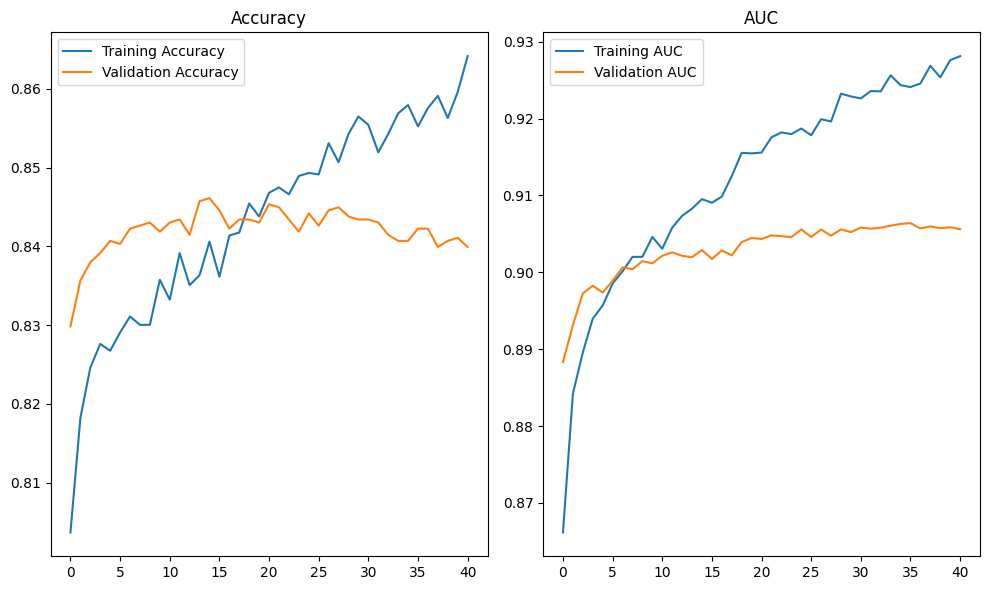

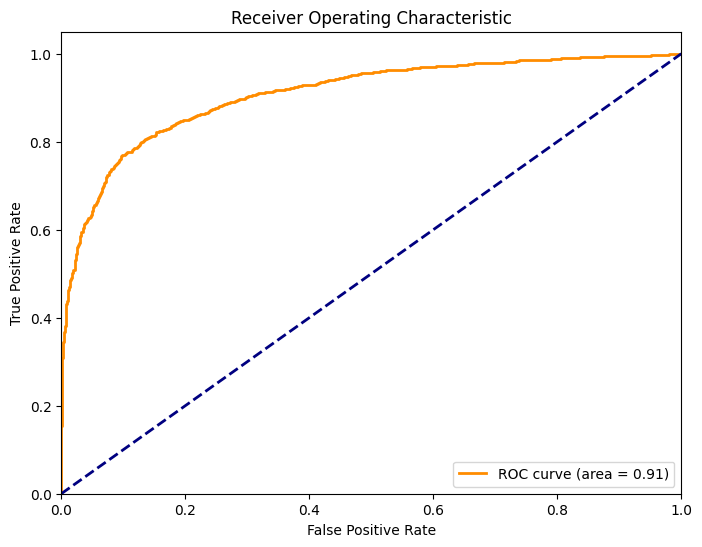

In [8]:
# Plot training and validation metrics
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['auc'], label='Training AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.title('AUC')
plt.legend()

plt.tight_layout()
plt.show()

# Plot ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test_any, y_pred_any)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % auc_score)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()
